In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.configs.config import GEOMAGNETIC_INDICES_DIR
# Data definition
dst_event1 = (
    [15, 17, 18, 15, 15, 14, 14, 13, 14, 15, 15, 17, 18, 21, 21, 18, 18, 20, 22, 22, 21, 20, 20, 17]
    + [12, 10, 12, 21, 16, 7, 9, 16, 13, 15, 13, 3, -1, 1, 10, 23, 25, 66, -33, -131, -157, -277, -339, -308]
)

kp_event1 = (
    [0.667, 1.333, 0.667, 1.333, 1.000, 1.000, 2.333, 2.000]
    + [2.667, 2.667, 2.333, 2.000, 3.667, 7.667, 8.667, 8.667]
)

ap_event1 = (
    [3, 5, 3, 5, 4, 4, 9, 7]
    + [12, 12, 9, 7, 22, 179, 300, 300]
)

# 1. Generate datetime ranges
time_dst = pd.date_range(start="2024-05-09 00:00", periods=48, freq="1h")
# Place 3-hourly Kp/ap values at the midpoint of each 3-hour bin (01:30, 04:30, ...)
time_kp = pd.date_range(start="2024-05-09 01:30", periods=16, freq="3h")

my_font_size=25

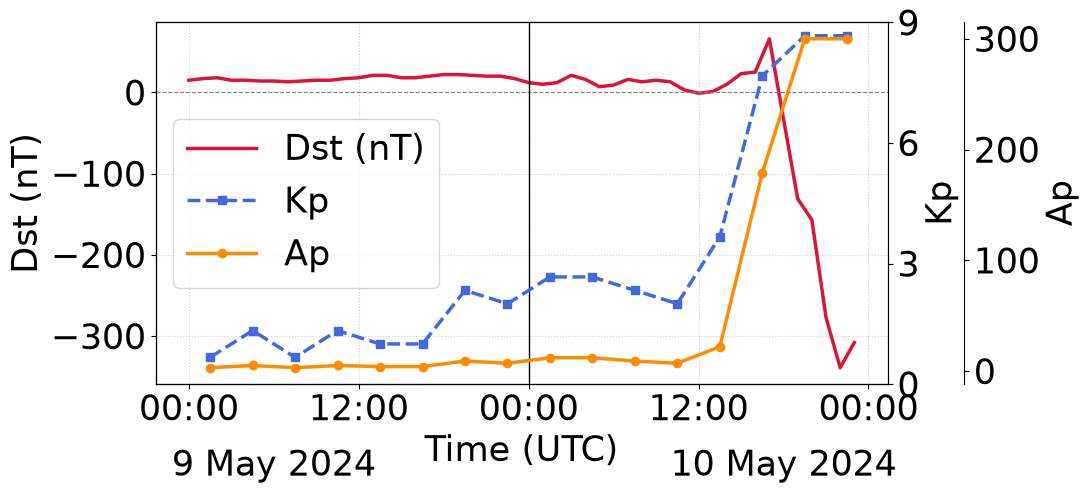

In [13]:
fig, ax1 = plt.subplots(figsize=(11, 5))

# Primary Y-Axis (Left): Dst Index
line1 = ax1.plot(time_dst, dst_event1, color='crimson', linewidth=2.5, label='Dst (nT)')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Dst (nT)', fontsize=my_font_size)
ax1.tick_params(axis='y')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.tick_params(axis='both', labelsize=my_font_size)

# Second Y-Axis (Right 1): Kp Index
ax2 = ax1.twinx()
line2 = ax2.plot(time_kp, kp_event1, color='royalblue', marker='s', linestyle='--', linewidth=2.5, label='Kp')
ax2.set_ylabel('Kp', fontsize=my_font_size)
ax2.tick_params(axis='y')
ax2.set_ylim(0, 9)
ax2.set_yticks([0, 3, 6, 9])
ax2.tick_params(axis='both', labelsize=my_font_size)

# Third Y-Axis (Right 2, Offset): ap Index
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 55))
line3 = ax3.plot(time_kp, ap_event1, color='darkorange', marker='o', linewidth=2.5, label='Ap')
ax3.set_ylabel('Ap', fontsize=my_font_size)
ax3.tick_params(axis='y')
ax3.tick_params(axis='both', labelsize=my_font_size)

# X-Axis Ticks setup (Every 12 hours)
tick_locations = pd.date_range(start="2024-05-09 00:00", end="2024-05-11 00:00", freq="12h")
ax1.set_xticks(tick_locations)
ax1.set_xticklabels([dt.strftime('%H:%M') for dt in tick_locations])
ax1.set_xlabel('Time (UTC)', fontsize=my_font_size)

# --- NEW: vertical line marking the day boundary ---
day_boundary = pd.Timestamp("2024-05-10 00:00")
ax1.axvline(day_boundary, color='black', linestyle='-', linewidth=1)

# --- NEW: date labels centered under each half ---
day1_center = pd.Timestamp("2024-05-09 6:00")
day2_center = pd.Timestamp("2024-05-10 18:00")

ax1.text(day1_center, -0.18, '9 May 2024', transform=ax1.get_xaxis_transform(),
          ha='center', va='top', fontsize=my_font_size)
ax1.text(day2_center, -0.18, '10 May 2024', transform=ax1.get_xaxis_transform(),
          ha='center', va='top', fontsize=my_font_size)

# Combined Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left', fontsize=my_font_size)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)  # make room for the date labels below the axis
plt.savefig(GEOMAGNETIC_INDICES_DIR/"geomag_9_10may2024.png", format="png", dpi=300, bbox_inches="tight")
plt.show()